# Genfit — toys independentes com massa e largura do ρ(1450) livres

Teste 03: mesmo procedimento do teste 02, com **12 parâmetros livres**: dez coeficientes cartesianos, massa e largura do ρ(1450). Um toy independente e um start diferente por fit. A referência ρ(770) permanece fixa; as demais massas e larguras também.

As verdades geradoras são fixas em todos os toys. Somente os starts variam. Os padrões de eventos e fits foram copiados do teste 02; o ajuste de dinâmica e sua normalização dependente dos parâmetros aumentam o custo computacional.

In [1]:
from pathlib import Path
import sys

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/dalitzplotfitter').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Abra o notebook dentro do repositório DalitzPlotFitter.')
sys.path.insert(0, str(ROOT / 'src'))
from IPython.display import display
from time import perf_counter
import numpy as np
import pandas as pd
import jax.numpy as jnp
import matplotlib.pyplot as plt

from dataclasses import dataclass

from dalitzplotfitter import (
    DecayChannel,
    DecayModel,
    FitSession,
    GounarisSakurai,
    Parameter,
    RealImag,
    RelativisticBreitWigner,
    Resonance,
    enable_x64,
    generate_signal_toy,
)

enable_x64()

SEED = 20260905
N_EVENTS = 100_000
TOY_METHOD = "accept-reject"
NORMALIZATION_METHOD = "gauss-legendre"

channel = DecayChannel("B+", ("pi+", "pi+", "pi-"))
M_PI = float(channel.daughter_masses[0])

print("Toy size:", N_EVENTS)
print("Toy method:", TOY_METHOD)
print("Normalization:", NORMALIZATION_METHOD)

N_FITS = 100
START_SEED = SEED + 1
START_SIGMA = 0.30  # desvio absoluto de x e y em torno da verdade
NCALL = 20_000
STRATEGY = 1
TOLERANCE = 1e-4
assert N_EVENTS > 0 and N_FITS >= 2 and START_SIGMA > 0

# GeV. Estimativas PDG usadas apenas como escala da randomização inicial.
RHO1450_MASS = 1.465
RHO1450_WIDTH = 0.400
DYNAMICS_START_SEED = SEED + 2
DYNAMICS_START_SIGMA = {'rho1450.mass': 0.025, 'rho1450.width': 0.060}
# Limites físicos amplos, não intervalos de +/-1 sigma.
DYNAMICS_BOUNDS = {
    'rho1450.mass': (2 * M_PI + 1e-6, float(channel.parent_mass) - M_PI - 1e-6),
    'rho1450.width': (1e-6, None),
}
assert all(s > 0 for s in DYNAMICS_START_SIGMA.values())

Toy size: 100000
Toy method: accept-reject
Normalization: gauss-legendre


## Modelo gerador
Coeficientes e dinâmica reutilizados do estudo isobárico de fechamento existente. As duas partículas π⁺ são tratadas pelo modelo do canal.

In [2]:
TRUTH_COEFFICIENTS = {
    "rho770":    dict(x= 1.000, y= 0.000),
    "omega782":  dict(x= 0.091, y=-0.007),
    "f2_1270":   dict(x= 0.291, y= 0.204),
    "rho1450":   dict(x=-0.223, y= 0.191),
    "rho3_1690": dict(x= 0.073, y=-0.045),
    "sigma":     dict(x=-0.485, y= 0.284),
}

def truth_coefficient(name):
    p = TRUTH_COEFFICIENTS[name]
    return RealImag(p["x"], p["y"])


@dataclass(frozen=True)
class PaperSigmaPole:
    # LHCb Eq. (16): A_sigma(m) = 1 / (s_sigma - m^2)
    def __call__(self, mass, context):
        m = jnp.asarray(mass)
        pole = jnp.asarray(context.pole_mass) - 1j * jnp.asarray(context.pole_width)
        s_sigma = pole**2
        return 1.0 / (s_sigma - m**2)


def isobar_components(coefficient_factory, *, rho_mass=RHO1450_MASS,
                      rho_width=RHO1450_WIDTH):
    return [
        Resonance(
            "rho770", (0, 2), coefficient_factory("rho770"),
            mass=0.7708, width=0.1534, spin=1,
            lineshape=GounarisSakurai(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "omega782", (0, 2), coefficient_factory("omega782"),
            mass=0.78265, width=0.00849, spin=1,
            lineshape=RelativisticBreitWigner(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "f2_1270", (0, 2), coefficient_factory("f2_1270"),
            mass=1.2755, width=0.1867, spin=2,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "rho1450", (0, 2), coefficient_factory("rho1450"),
            mass=rho_mass, width=rho_width, spin=1,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "rho3_1690", (0, 2), coefficient_factory("rho3_1690"),
            mass=1.6888, width=0.161, spin=3,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "sigma", (0, 2), coefficient_factory("sigma"),
            mass=0.563, width=0.350, spin=0,
            lineshape=PaperSigmaPole(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
    ]


generator = DecayModel(
    channel,
    isobar_components(truth_coefficient),
    normalize_components=True,
    normalization_method=NORMALIZATION_METHOD,
)

print("Generator normalization points:", generator.normalization_sample.size)

INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=0.782650 GeV, Gamma=8.490 MeV; m23: m0=0.782650 GeV, Gamma=8.490 MeV); using adaptive Gauss-Legendre normalization.
Generator normalization points: 2080469


## Sementes independentes
Cada toy usa uma semente distinta. O gerador e a integração de normalização são compartilhados; os eventos são gerados novamente dentro do loop. As amostras não são acumuladas em memória.

In [3]:
toy_seeds = [int(s.generate_state(1, dtype=np.uint64)[0])
             for s in np.random.SeedSequence(SEED).spawn(N_FITS)]
assert len(set(toy_seeds)) == N_FITS
print('Primeiras sementes:', toy_seeds[:5])

Primeiras sementes: [5734163613718072789, 10843568836493112964, 5360109053914373194, 9040270409388520618, 6838429578534984449]


## Modelo de ajuste e incertezas dos starts
`rho1450.mass` e `rho1450.width` são parâmetros de dinâmica, propagados à amplitude e à normalização durante o fit.

Usamos **m = 1,465 ± 0,025 GeV** e **Γ = 0,400 ± 0,060 GeV**, estimativas do [PDG](https://pdgprod.lbl.gov/pdgprod/pdgLive/Particle.action?init=0&node=M105), consultadas em 09/09/2026. Para este teste adotamos gaussianas independentes com esses desvios; isso é uma escolha de randomização, sem penalidade gaussiana na NLL. Starts fora dos limites físicos são ressorteados. O passo numérico do minimizador é configurado separadamente.

In [4]:
def floating_coefficient(name):
    truth = TRUTH_COEFFICIENTS[name]
    reference = name == "rho770"
    return RealImag(
        Parameter.coefficient(
            f"{name}.x",
            truth["x"],
            owner=name,
            fixed=reference,
            step=0.01,
        ),
        Parameter.coefficient(
            f"{name}.y",
            truth["y"],
            owner=name,
            fixed=reference,
            step=0.01,
        ),
    )


fit_model = DecayModel(
    channel,
    isobar_components(
        floating_coefficient,
        rho_mass=Parameter.dynamics(
            'rho1450.mass', RHO1450_MASS, owner='rho1450',
            bounds=DYNAMICS_BOUNDS['rho1450.mass'], step=0.001,
        ),
        rho_width=Parameter.dynamics(
            'rho1450.width', RHO1450_WIDTH, owner='rho1450',
            bounds=DYNAMICS_BOUNDS['rho1450.width'], step=0.005,
        ),
    ),
    normalize_components=True,
    normalization_method=NORMALIZATION_METHOD,
)


print('Parâmetros livres:', sum(not p.fixed for p in fit_model.parameters))
assert sum(not p.fixed for p in fit_model.parameters) == 12

Parâmetros livres: 12


## Starts e logs
Cada start é sorteado em torno da verdade, sem usar o resultado anterior. Cada execução cria `genfit/logs/rho1450_free_<data>_<id>/`, com logs individuais, configuração, sementes, starts e CSVs atualizados após cada ajuste. A semente e o modelo permitem regenerar um toy no mesmo ambiente; os eventos não são salvos em disco.

Os coeficientes mantêm `START_SIGMA` e o mesmo fluxo de números aleatórios do teste 02. Massa e largura usam uma semente separada (`DYNAMICS_START_SEED`); liberar a dinâmica não altera os starts dos coeficientes nem as sementes dos toys.


Memória: apenas tabelas numéricas são acumuladas. Minuit, sessão e toy são liberados em `finally`, com coleta de lixo e limpeza dos caches JAX. Isso pode aumentar a recompilação. A grade compartilhada permanece em memória; o pico de um único fit não é reduzido.


In [5]:
free_parameters = tuple(p for p in fit_model.parameters if not p.fixed)
truth_values = {p.name: float(p.value) for p in fit_model.parameters}
rng = np.random.default_rng(START_SEED)
starts = [
    {p.name: float(truth_values[p.name] + rng.normal(0, START_SIGMA))
     for p in free_parameters if p.name not in DYNAMICS_START_SIGMA}
    for _ in range(N_FITS)
]
dynamics_rng = np.random.default_rng(DYNAMICS_START_SEED)
for start in starts:
    for name, sigma in DYNAMICS_START_SIGMA.items():
        low, high = DYNAMICS_BOUNDS[name]
        for attempt in range(10_000):
            value = float(dynamics_rng.normal(truth_values[name], sigma))
            if (low is None or value > low) and (high is None or value < high):
                start[name] = value
                break
        else:
            raise RuntimeError(f'Não foi possível sortear um start físico: {name}')
assert len({tuple(s.items()) for s in starts}) == N_FITS
starts_table = pd.DataFrame(starts).rename_axis('fit_id')
starts_table.insert(0, 'toy_seed', toy_seeds)
display(starts_table)

,toy_seed,omega782.x,omega782.y,f2_1270.x,f2_1270.y,rho1450.x,rho1450.y,rho3_1690.x,rho3_1690.y,sigma.x,sigma.y,rho1450.mass,rho1450.width
fit_id,,,,,,,,,,,,,
0,5734163613718072789,0.241749,-0.122138,0.534609,-0.070515,-0.236086,0.449812,0.371532,0.382253,-0.534465,0.428955,1.480406,0.354780
1,10843568836493112964,-0.312971,-0.021339,0.111989,-0.056520,-0.366324,0.298341,0.379612,0.642962,-0.719463,0.394515,1.403081,0.344489
2,5360109053914373194,0.315112,0.261491,0.856246,0.437698,0.347994,0.414155,0.063495,-0.087406,-0.453773,-0.007044,1.467077,0.395865
3,9040270409388520618,0.115948,-0.249547,0.002909,-0.058741,-0.169407,0.140649,-0.079130,-0.285135,-0.152160,0.337011,1.472757,0.400060
4,6838429578534984449,-0.059551,-0.092367,0.595006,0.271837,0.550472,0.082273,-0.278738,0.333257,-0.178080,0.667313,1.449152,0.393528
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,12038175148865763224,-0.237473,-0.285244,0.257844,0.062641,-0.277427,0.382867,0.432123,-0.270427,-0.510126,0.078179,1.423804,0.356466
96,16261880647681849399,-0.032596,-0.316234,0.316967,0.087974,-0.519850,0.243562,0.440057,0.254213,-0.580708,-0.045632,1.474442,0.406385
97,18105346768116085406,0.285832,0.278280,0.113078,0.229741,0.168671,-0.032562,-0.300615,0.198428,-0.062185,0.288133,1.473520,0.430128


In [6]:
from contextlib import redirect_stdout, redirect_stderr
from datetime import datetime, timezone
import json
import traceback
import gc
import jax
from uuid import uuid4

# Uma pasta nova a cada execução desta célula, sem sobrescrever logs anteriores.
run_id = 'rho1450_free_' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ') + '_' + uuid4().hex[:8]
log_dir = ROOT / 'genfit' / 'logs' / run_id
log_dir.mkdir(parents=True, exist_ok=False)
config = dict(seed=SEED, start_seed=START_SEED, n_events=N_EVENTS,
              n_fits=N_FITS, start_sigma=START_SIGMA, ncall=NCALL,
              strategy=STRATEGY, tolerance=TOLERANCE,
              toy_seeds=toy_seeds, toy_method=TOY_METHOD,
              normalization_method=NORMALIZATION_METHOD,
              truth_values=truth_values, starts=starts,
              dynamics_start_seed=DYNAMICS_START_SEED,
              dynamics_start_sigma=DYNAMICS_START_SIGMA,
              dynamics_bounds=DYNAMICS_BOUNDS,
              dynamics_source='https://pdgprod.lbl.gov/pdgprod/pdgLive/Particle.action?init=0&node=M105')
(log_dir / 'config.json').write_text(
    json.dumps(config, indent=2, ensure_ascii=False), encoding='utf-8')
starts_table.to_csv(log_dir / 'starts.csv')
print(f'Logs desta execução: {log_dir}')

# Remover referências de execuções anteriores; conservar apenas tabelas numéricas.
for name in ('results', 'result', 'session', 'toy'):
    globals().pop(name, None)
gc.collect()
jax.clear_caches()
summary_rows = []
parameter_rows = []
for fit_id, start_values in enumerate(starts):
    session = toy = result = None
    try:
        toy_seed = toy_seeds[fit_id]
        truth_nll = np.nan
        generation_seconds = np.nan
        t0 = perf_counter()
        log_path = log_dir / f'fit_{fit_id:03d}.log'
        with log_path.open('w', encoding='utf-8', buffering=1) as log:
            with redirect_stdout(log), redirect_stderr(log):
                print(f'fit_id={fit_id}, toy_seed={toy_seed}')
                print('start_values=' + json.dumps(start_values, sort_keys=True))
                print('Configuração completa em config.json')
                try:
                    generation_start = perf_counter()
                    toy = generate_signal_toy(
                        generator, N_EVENTS, seed=toy_seed, method=TOY_METHOD,
                        include_momenta=False,
                    )
                    assert toy.size == N_EVENTS
                    generation_seconds = perf_counter() - generation_start
                    session = FitSession(fit_model, toy)
                    truth_nll = float(session.objective(truth_values))
                    print(f'n_events={toy.size}, truth_nll={truth_nll:.9f}')
                    result = session.fit(
                        start_values=dict(start_values), simplex=False, strategy=STRATEGY,
                        hesse=True, tolerance=TOLERANCE, ncall=NCALL, verbose=2,
                    )
                    print(result)
                    session.print_result(result)
                    failure = None
                except Exception as exc:
                    traceback.print_exc()
                    result = None
                    failure = repr(exc)
                finally:
                    print(f'elapsed_seconds={perf_counter()-t0:.6f}')
        if result is None:
            summary_rows.append(dict(fit_id=fit_id, toy_seed=toy_seed, valid=False, nll=np.nan,
                                     truth_nll=truth_nll, nll_minus_truth=np.nan,
                                     generation_seconds=generation_seconds,
                                     seconds=perf_counter()-t0, exception=failure,
                                     log_file=str(log_path)))
            pd.DataFrame(summary_rows).to_csv(log_dir / 'summary.csv', index=False)
            print(f'Fit {fit_id}: falhou: {failure}; log: {log_path.name}', flush=True)
            continue
        summary_rows.append(dict(
            fit_id=fit_id, toy_seed=toy_seed, valid=bool(result.valid), nll=float(result.fval),
            truth_nll=truth_nll, nll_minus_truth=float(result.fval)-truth_nll,
            generation_seconds=generation_seconds,
            edm=float(result.fmin.edm), nfcn=int(result.nfcn),
            accurate_covariance=bool(result.fmin.has_accurate_covar),
            call_limit=bool(result.fmin.has_reached_call_limit),
            parameters_at_limit=bool(result.fmin.has_parameters_at_limit),
            seconds=perf_counter()-t0, exception='', log_file=str(log_path),
        ))
        values = session.result_values(result)
        for p in session.parameters:
            error = 0.0 if p.fixed else float(result.errors[p.name])
            parameter_rows.append(dict(
                fit_id=fit_id, parameter=p.name, fixed=p.fixed,
                truth=truth_values[p.name], start=start_values.get(p.name, p.value),
                value=values[p.name], error=error,
                pull=(values[p.name]-truth_values[p.name])/error if error > 0 else np.nan,
            ))
        pd.DataFrame(summary_rows).to_csv(log_dir / 'summary.csv', index=False)
        pd.DataFrame(parameter_rows).to_csv(log_dir / 'parameters.csv', index=False)
        print(f'Fit {fit_id}: valid={result.valid}, NLL={result.fval:.6f}, '
              f'EDM={result.fmin.edm:.2e}', flush=True)
    finally:
        # Liberar também em caso de exceção, continue ou interrupção.
        result = None
        session = None
        toy = None
        gc.collect()
        jax.clear_caches()
        gc.collect()

summary = pd.DataFrame(summary_rows).set_index('fit_id')
parameters = pd.DataFrame(parameter_rows)
valid = summary['valid'] & np.isfinite(summary['nll'])
summary.to_csv(log_dir / 'summary.csv')
parameters.to_csv(log_dir / 'parameters.csv', index=False)
display(summary)
print(f'Ajustes válidos: {valid.sum()}/{N_FITS}')
print('Cada nova sessão pode incluir compilação JAX; tempos incluem geração e ajuste.')

Logs desta execução: /home/juan-leite/Work/DalitzPlotFitter/genfit/logs/rho1450_free_20260909T223453_886008Z_db0ecdfd
Fit 0: valid=True, NLL=421649.877917, EDM=1.94e-08
Fit 1: valid=True, NLL=421889.207272, EDM=5.56e-08
Fit 2: valid=True, NLL=420697.379900, EDM=3.35e-09
Fit 3: valid=True, NLL=421726.060254, EDM=9.22e-10
Fit 4: valid=True, NLL=423838.419861, EDM=1.17e-08
Fit 5: valid=True, NLL=421094.485717, EDM=1.63e-09
Fit 6: valid=True, NLL=420638.382847, EDM=5.79e-08
Fit 7: valid=True, NLL=421788.110373, EDM=4.70e-08
Fit 8: valid=True, NLL=421514.707686, EDM=6.03e-08
Fit 9: valid=True, NLL=420965.035860, EDM=5.78e-08
Fit 10: valid=True, NLL=420917.090093, EDM=2.08e-08
Fit 11: valid=True, NLL=421502.805345, EDM=6.02e-08
Fit 12: valid=True, NLL=421177.253188, EDM=1.72e-08
Fit 13: valid=True, NLL=422067.637941, EDM=3.30e-09
Fit 14: valid=True, NLL=422047.544206, EDM=6.17e-09
Fit 15: valid=True, NLL=421322.432262, EDM=5.47e-09
Fit 16: valid=True, NLL=421222.592872, EDM=5.46e-10
Fit 17: 

,toy_seed,valid,nll,truth_nll,nll_minus_truth,generation_seconds,edm,nfcn,accurate_covariance,call_limit,parameters_at_limit,seconds,exception,log_file
fit_id,,,,,,,,,,,,,,
0,5734163613718072789,True,421649.877917,421655.069136,-5.191219,11.658096,1.942715e-08,383,True,False,False,64.189196,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...
1,10843568836493112964,True,421889.207272,420759.603838,1129.603434,7.226409,5.556388e-08,462,True,False,False,61.837233,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...
2,5360109053914373194,True,420697.379900,420702.988122,-5.608221,6.565523,3.350650e-09,391,True,False,False,58.097279,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...
3,9040270409388520618,True,421726.060254,421729.650066,-3.589812,6.781203,9.221368e-10,275,True,False,False,53.002922,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...
4,6838429578534984449,True,423838.419861,420917.018700,2921.401161,6.895564,1.169052e-08,498,True,False,False,64.017523,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,12038175148865763224,True,420919.917594,420928.701927,-8.784333,7.492417,3.165290e-10,376,True,False,False,61.868721,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...
96,16261880647681849399,True,421559.512205,421563.543949,-4.031745,7.209875,3.529258e-10,386,True,False,False,61.539994,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...
97,18105346768116085406,True,421116.884675,421123.451966,-6.567291,8.687171,1.406813e-08,416,True,False,False,67.060618,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...


Ajustes válidos: 100/100
Cada nova sessão pode incluir compilação JAX; tempos incluem geração e ajuste.


## Diagnósticos do ensemble
Não comparamos NLL absoluta entre amostras distintas. `nll_minus_truth` compara o fit à verdade **no próprio toy**: um valor positivo relevante revela que o ajuste ficou pior que um ponto conhecido. Um valor negativo não prova que o mínimo global foi encontrado.

Os pulls são `(valor − verdade) / erro HESSE`. Mostramos apenas fits válidos com erros finitos e positivos, informando a seleção. Média próxima de zero e largura próxima de um são referências para um ensemble suficientemente grande; dez toys servem somente como teste rápido. Mínimos locais podem produzir caudas, e a seleção por validade também pode afetar a distribuição.

,n,mean_pull,std_pull,mean_value,mean_error
parameter,,,,,
f2_1270.x,100,-0.520889,3.688504,0.289576,0.003576
f2_1270.y,100,-1.132297,5.084502,0.200231,0.003430
omega782.x,100,-17.862781,60.607487,0.042818,0.003257
omega782.y,100,-4.104676,13.240115,-0.018662,0.003652
rho1450.mass,100,0.181675,16.244783,1.492288,0.004831
rho1450.width,100,0.299273,2.389224,0.412470,0.010198
rho1450.x,100,1.580892,9.562916,-0.213824,0.005143
rho1450.y,100,-1.892400,12.516323,0.183985,0.004985
rho3_1690.x,100,-0.175691,1.252549,0.072541,0.002885


Fits válidos selecionados: 100/100
Fits com NLL acima da verdade por mais de 0.001: [1, 4, 20, 35, 43, 50, 56, 75, 89]


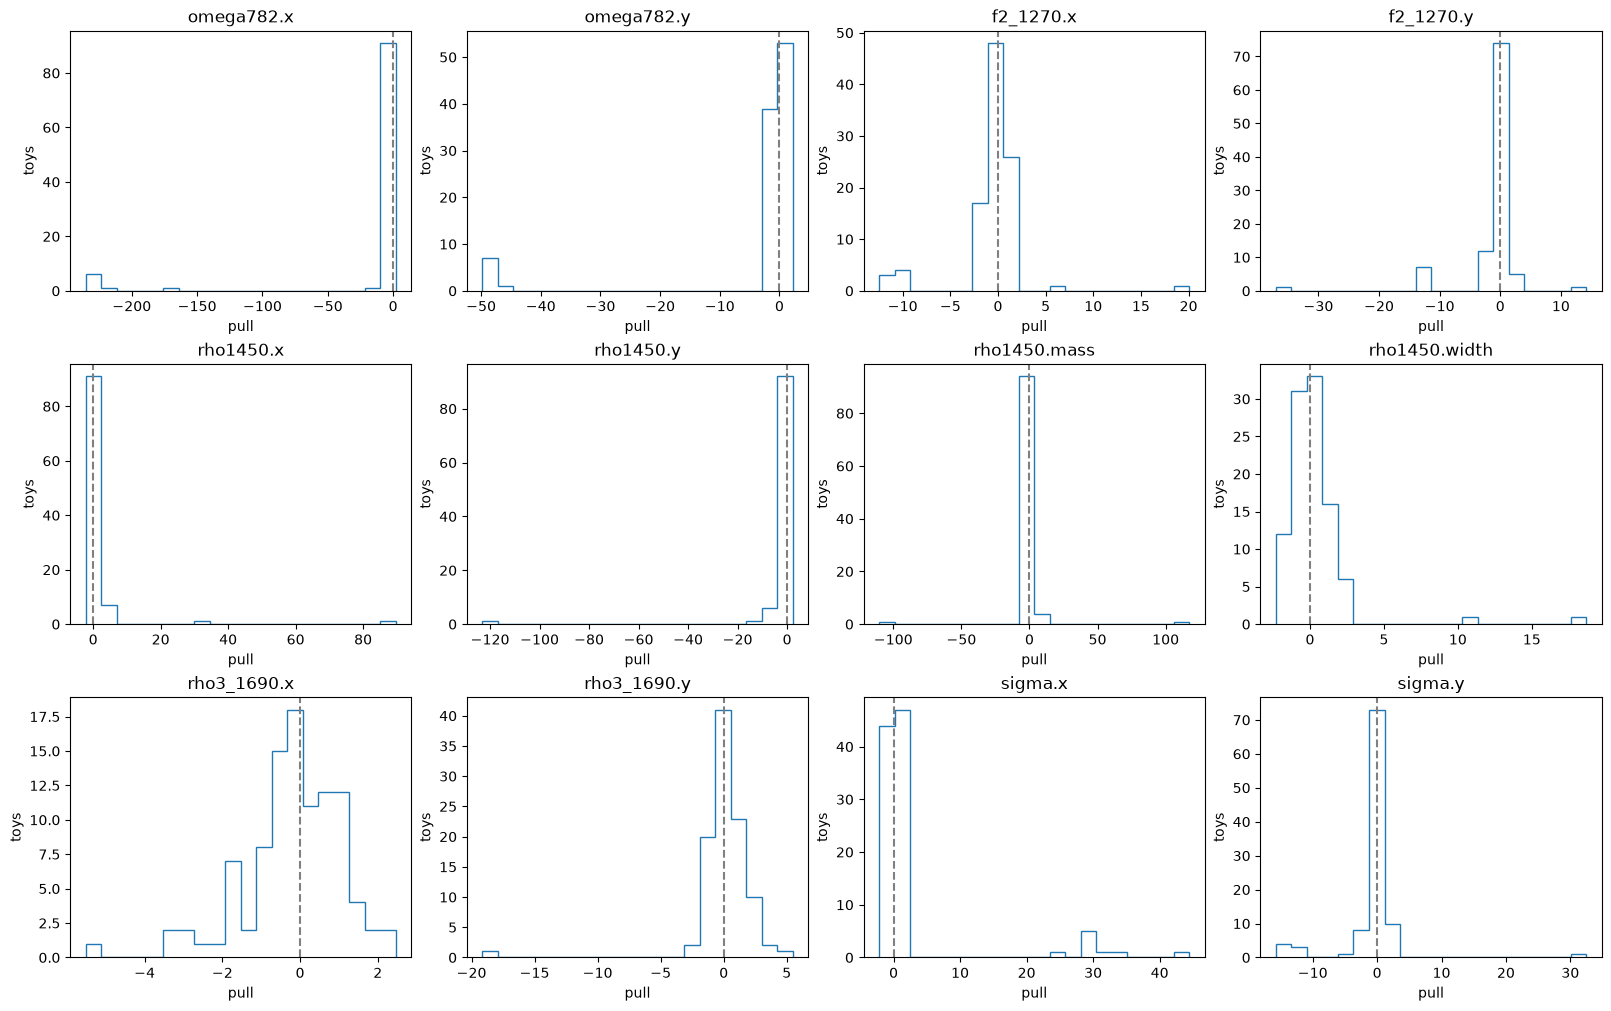

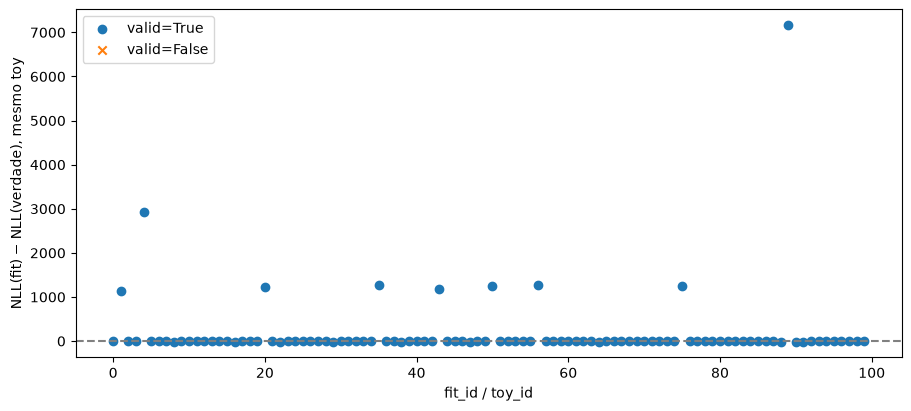

In [7]:
if parameters.empty:
    print('Nenhum resultado disponível; consulte os logs de exceção.')
else:
    valid_ids = summary.index[valid]
    selected = parameters.loc[
        parameters.fit_id.isin(valid_ids) & ~parameters.fixed
        & np.isfinite(parameters.pull) & (parameters.error > 0)
    ]
    pull_summary = selected.groupby('parameter').agg(
        n=('pull', 'size'), mean_pull=('pull', 'mean'),
        std_pull=('pull', 'std'), mean_value=('value', 'mean'),
        mean_error=('error', 'mean'),
    )
    display(pull_summary)
    pull_summary.to_csv(log_dir / 'pull_summary.csv')
    print(f'Fits válidos selecionados: {len(valid_ids)}/{N_FITS}')
    print('Fits com NLL acima da verdade por mais de 0.001:',
          summary.index[summary.nll_minus_truth > 1e-3].tolist())
    fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)
    for ax, p in zip(axes.flat, free_parameters):
        values = selected.loc[selected.parameter == p.name, 'pull']
        ax.hist(values, bins=min(20, max(5, len(values))), histtype='step')
        ax.axvline(0, color='grey', linestyle='--')
        ax.set(title=p.name, xlabel='pull', ylabel='toys')
    plt.show()
    fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
    for state, marker in [(True, 'o'), (False, 'x')]:
        rows = summary.loc[summary.valid == state]
        ax.scatter(rows.index, rows.nll_minus_truth, marker=marker,
                   label=f'valid={state}')
    ax.axhline(0, color='grey', linestyle='--')
    ax.set(xlabel='fit_id / toy_id', ylabel='NLL(fit) − NLL(verdade), mesmo toy')
    ax.legend()
    plt.show()

## Como interpretar
- Verifique validade, EDM, covariância, exceções e limite de chamadas em `summary`.
- Consulte `parameters` e as distribuições de pulls para avaliar recuperação dos coeficientes.
- Mínimos locais podem existir mesmo com `valid=True`. Reajustar um toy suspeito exige sua semente registrada e novos starts, mantendo essa amostra fixa.
- Não escolha um “melhor toy” pela menor NLL entre amostras diferentes.
- Aumente `N_FITS` para um estudo estatístico; a geração e uma nova sessão por toy tornam este teste mais caro que o teste 01.
- Massa, largura, seus erros e starts são registrados em GeV em `parameters.csv`; seus pulls aparecem junto aos coeficientes.
- Inspecione `parameters_at_limit`: erros HESSE e pulls exigem cautela quando a solução encosta nos limites físicos.